#### Скачайте данные
Загрузите данные, выполнив код ниже.

In [9]:
# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd

data = pd.read_csv("../data/raw/NetflixShows.csv", encoding='cp437', sep=';')
del data['ratingDescription'], data['user rating size']

In [2]:
data

,title,rating,ratingLevel,release year,user rating score
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",2004,82.0
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",2006,NaN
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,98.0
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,2008,98.0
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,2014,94.0
...,...,...,...,...,...
995,The BFG,PG,"for action/peril, some scary moments and brief...",2016,97.0
996,The Secret Life of Pets,PG,for action and some rude humor,2016,NaN
997,Precious Puppies,TV-G,Suitable for all ages.,2003,NaN
998,Beary Tales,TV-G,Suitable for all ages.,2013,NaN


#### Удалите из данных дубликаты.
- Почему они возникли?
- Много ли их? В каких группах их больше всего?

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   str    
 1   rating             1000 non-null   str    
 2   ratingLevel        941 non-null    str    
 3   release year       1000 non-null   int64  
 4   user rating score  605 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 109.3 KB


In [4]:
data.nunique()

title                496
rating                13
ratingLevel           99
release year          35
user rating score     42
dtype: int64

Найдем количество полных дублей, и удалим их из датасета при наличии.

In [5]:
duplicate = data.duplicated()
duplicate.sum()

np.int64(500)

500 строк в датасете - полные дубли, удалим их. 

In [6]:
data = data.drop_duplicates()
data.shape

(500, 5)

In [31]:
data["title"].nunique()

496

Проверим дублирование названий шоу и какие данные отличаются у одинаковых шоу.  

In [8]:
title_duplicate = data["title"].value_counts()
title_duplicate = title_duplicate[title_duplicate > 1]
title_duplicate.shape

(4,)

После удаления полных дублей осталось 4 шоу с повторяющимися названиями.
Выведем эти строки и найдем какие колонки отличаются у одинаковых шоу. 

In [9]:
title_duplicate.info()

<class 'pandas.Series'>
Index: 4 entries, Skins to Goosebumps
Series name: count
Non-Null Count  Dtype
--------------  -----
4 non-null      int64
dtypes: int64(1)
memory usage: 115.0 bytes


In [10]:
twice_show = data[data["title"].isin(title_duplicate.index)]
twice_show

,title,rating,ratingLevel,release year,user rating score
151,Skins,TV-MA,For mature audiences. May not be suitable for...,2013,NaN
167,Bordertown,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,86.0
181,Skins,TV-MA,NaN,2017,NaN
449,Bordertown,TV-MA,For mature audiences. May not be suitable for...,2016,NaN
504,Star Wars: The Clone Wars,PG,"sci-fi action violence throughout, brief langu...",2008,57.0
512,Star Wars: The Clone Wars,TV-PG,Parental guidance suggested. May not be suitab...,2014,93.0
568,Goosebumps,TV-Y7,Suitable for children ages 7 and older,1998,88.0
632,Goosebumps,PG,"scary and intense creature action and images, ...",2015,90.0


# У шоу Skins, Star Wars: The Clone Wars, Goosebumps отличаются год выпуска значит это разные шоу, не дубли.  
# У шоу Bordertown отличается рейтинг (14+) и (18+).??

С дублями в датасете разобрались, проверим датасет на количетсво незаполненных ячеек.

In [11]:
data.isnull().sum()

title                  0
rating                 0
ratingLevel           33
release year           0
user rating score    244
dtype: int64

ratingLevel это описание рейтинговой группы. Заполним пустые значения описанием рейтинга, из заполненых ячеек того же рейтинга.  
user rating score это оценка пользователей, можно заполнить средним значением всего датасета, либо средним значением группировки по возрастному рейтингу


Нужно получить описание возрастного рейтинга (ratingLevel) для каждого уникального рейтинга (rating)

In [12]:
data.nunique()

title                496
rating                13
ratingLevel           99
release year          35
user rating score     42
dtype: int64

Так как количество уникальных ячеек в rating и ratingLevel разное, возьмем самые часто встречающиеся описания для каждого рейтинга.

In [13]:
ratingLevels = data.groupby("rating")["ratingLevel"].agg(lambda x: x.mode().iloc[0])
ratingLevels

rating
G                   General Audiences. Suitable for all ages.
NR                             This movie has not been rated.
PG          Parental guidance suggested. May not be suitab...
PG-13       For some rude and suggestive material, and for...
R           Restricted. May be inappropriate for children ...
TV-14       Parents strongly cautioned. May be unsuitable ...
TV-G                                   Suitable for all ages.
TV-MA       For mature audiences.  May not be suitable for...
TV-PG       Parental guidance suggested. May not be suitab...
TV-Y                                   Suitable for all ages.
TV-Y7                  Suitable for children ages 7 and older
TV-Y7-FV    Suitable for children ages 7 and older.  Conte...
UR          This movie has not been rated. Intended for ad...
Name: ratingLevel, dtype: str

In [14]:
data["ratingLevel"] = data["ratingLevel"].fillna(data["rating"].map(ratingLevels))

Теперь заполним пользовательскую оценку, медианой по рейтингу. 

In [15]:
UserScore = data.groupby("rating")["user rating score"].agg(lambda x: x.median())
UserScore

rating
G           70.0
NR          77.0
PG          86.0
PG-13       68.0
R           79.0
TV-14       86.0
TV-G        74.0
TV-MA       89.0
TV-PG       88.0
TV-Y        75.5
TV-Y7       74.5
TV-Y7-FV    72.0
UR           NaN
Name: user rating score, dtype: float64

Для рейтинга видим пустое значение, заполним 0.

In [16]:
UserScore = UserScore.fillna(0)
UserScore

rating
G           70.0
NR          77.0
PG          86.0
PG-13       68.0
R           79.0
TV-14       86.0
TV-G        74.0
TV-MA       89.0
TV-PG       88.0
TV-Y        75.5
TV-Y7       74.5
TV-Y7-FV    72.0
UR           0.0
Name: user rating score, dtype: float64

# Есть ли смысл это заполнять????

In [32]:
data["user rating score"] = data["user rating score"].fillna(data["rating"].map(UserScore))

In [17]:
data.isnull().sum()

title                  0
rating                 0
ratingLevel            0
release year           0
user rating score    244
dtype: int64

Добавим новый признак, основанный от рейтинга. Объединим признаки рейтинга в группы пользователей (Kids, Teen, Adult, Family)

In [18]:
Groups = {

    'G': 'Family',
    'TV-G': 'Family',

    'PG': 'Parental Guidance',
    'TV-PG': 'Parental Guidance',

    'TV-Y': 'Kids',
    'TV-Y7': 'Kids',
    'TV-Y7-FV': 'Kids',

    'PG-13': 'Teen',
    'TV-14': 'Teen',

    'R': 'Adult',
    'TV-MA': 'Adult',

    'NR': 'Unrated',
    'UR': 'Unrated'
}

In [19]:
data["ageGroup"] = data["rating"].map(Groups)

In [20]:
data

,title,rating,ratingLevel,release year,user rating score,ageGroup
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",2004,82.0,Teen
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",2006,NaN,Adult
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,98.0,Teen
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,2008,98.0,Teen
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,2014,94.0,Parental Guidance
...,...,...,...,...,...,...
989,Russell Madness,PG,some rude humor and sports action,2015,NaN,Parental Guidance
993,Wiener Dog Internationals,G,General Audiences. Suitable for all ages.,2015,NaN,Family
994,Pup Star,G,General Audiences. Suitable for all ages.,2016,NaN,Family
997,Precious Puppies,TV-G,Suitable for all ages.,2003,NaN,Family


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='ageGroup', ylabel='user rating score'>

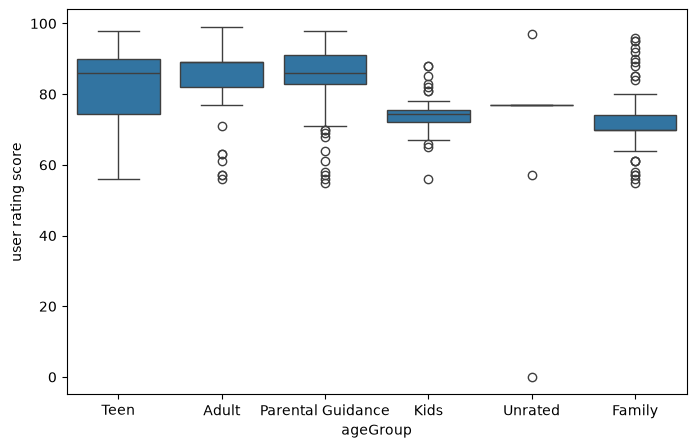

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='ageGroup', y='user rating score')

<Axes: xlabel='ageGroup', ylabel='release year'>

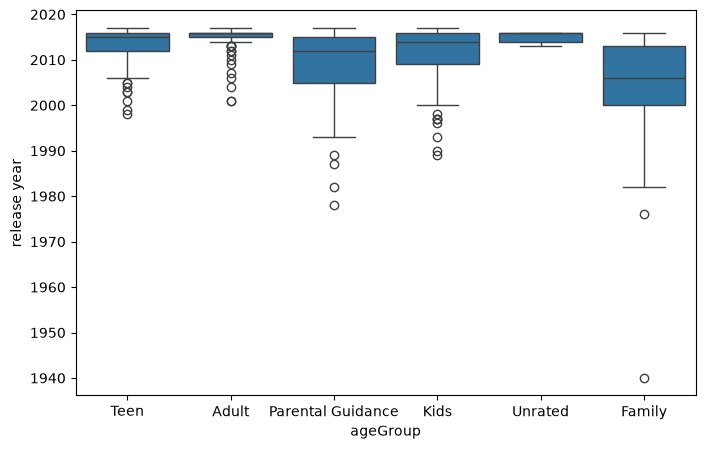

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='ageGroup', y='release year')

<Axes: xlabel='release year', ylabel='user rating score'>

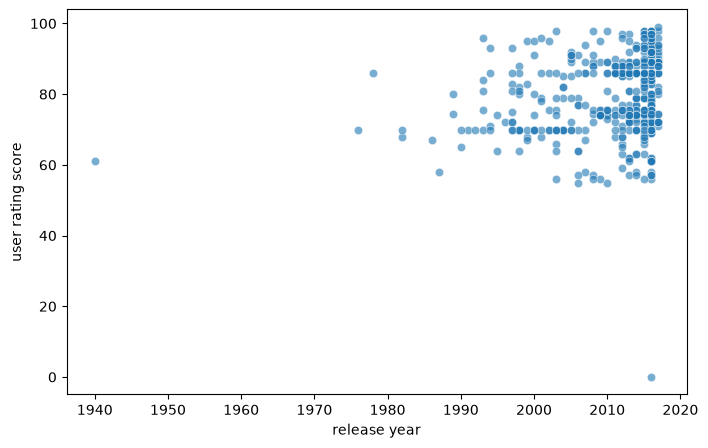

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data,
                x='release year',
                y='user rating score',
                alpha=0.6)

<Axes: xlabel='release year', ylabel='user rating score'>

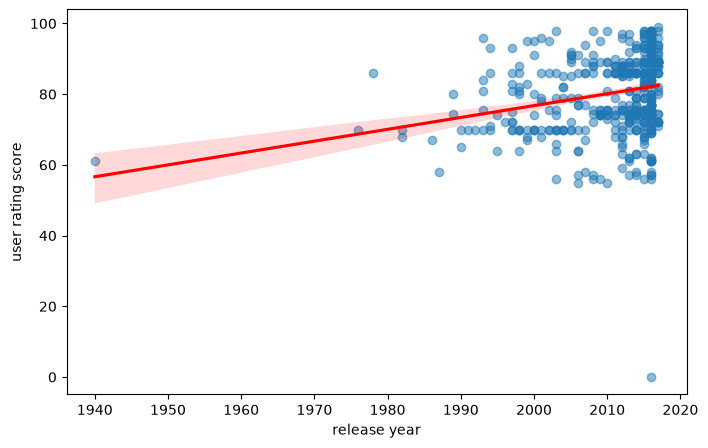

In [37]:
plt.figure(figsize=(8, 5))
sns.regplot(data=data,
            x='release year',
            y='user rating score',
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red'})

In [29]:
data.to_csv('../data/prepairedData.csv', sep=";", index=False)

In [30]:

external_data = pd.read_csv("../data/external/Netflix Dataset.csv", encoding='cp437', sep=',')

In [33]:
external_data['Title'] = external_data['Title'].str.lower().str.strip()
data['title'] = data['title'].str.lower().str.strip()

In [ ]:
common = external_data['Title'].isin(data['title']).sum()
print(common)

246
